# 基于 Prophet 的快递揽件需求预测与运力配置分析

**项目简介**

本项目基于公开的 **LaDe（Last-mile Delivery Dataset）上海揽件子集**数据集开展分析。LaDe 是目前公开的大规模末端物流配送数据集之一，包含真实物流场景下的揽件、派件、快递员及任务执行等信息，可用于物流需求预测、运力规划和配送优化等研究。

本项目以区域5的揽件业务为研究对象，首先对原始数据进行清洗与探索性分析，识别业务趋势、周周期及异常时段；随后基于 Prophet 建立短期揽件需求预测模型，并采用滚动时间窗口交叉验证评估模型性能，实现未来3天滚动预测；最后结合快递员历史作业数据，对揽件能力、人员结构及运力配置进行分析，识别核心作业人员承担主要业务量的运营规律，并讨论需求预测在人力配置中的应用边界，为末端物流运营管理提供数据支持。

数据来源：https://www.kaggle.com/datasets/paulkamande/lade-last-mile-delivery-dataset-shanghai-subset/data

## 0. 全局配置与公共函数

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
# ─────────────────────────────────────────────
# 全局常量
# ─────────────────────────────────────────────
DATA_FOLDER = r"D:\WORK\作品\transport"
PICKUP_FILE  = os.path.join(DATA_FOLDER, "pickup_sh.csv")

# 揽件量 Top5 区域
TOP5 = [5, 43, 15, 54, 35]

# 各区域早期异常时段（数据缺失/不完整，含端点）
REMOVE_RULES = {
    54: (520, 601),   # 5月20日 ~ 6月1日
    43: (525, 602),   # 5月25日 ~ 6月2日
    35: (526, 602),   # 5月26日 ~ 6月2日
    15: (601, 602),   # 6月1日  ~ 6月2日
    5:  (529, 602),   # 5月29日 ~ 6月2日
}

# ─────────────────────────────────────────────
# 中文字体（全局生效）
# ─────────────────────────────────────────────
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False


# ─────────────────────────────────────────────
# 公共函数
# ─────────────────────────────────────────────
def load_pickup() -> pd.DataFrame:
    """读取揽件原始数据，确保 ds 列为整数。"""
    df = pd.read_csv(PICKUP_FILE, encoding='utf-8')
    df['ds'] = df['ds'].astype(int)
    return df


def filter_top5(df: pd.DataFrame) -> pd.DataFrame:
    """筛选 Top5 区域并剔除各区域早期异常时段。"""
    df = df[df['region_id'].isin(TOP5)].copy()
    for region, (start, end) in REMOVE_RULES.items():
        mask = (
            (df['region_id'] == region) &
            (df['ds'] >= start) &
            (df['ds'] <= end)
        )
        df = df[~mask]
    return df.reset_index(drop=True)


def make_daily(df: pd.DataFrame) -> pd.DataFrame:
    """
    按区域+日期聚合每日揽件量，并附加可读的日期标签列。
    返回列：region_id | ds | date_label | count
    """
    daily = (
        df.groupby(['region_id', 'ds'])
          .size()
          .reset_index(name='count')
          .sort_values(['region_id', 'ds'])
          .reset_index(drop=True)
    )
    month = daily['ds'] // 100
    day   = daily['ds'] % 100
    daily['date_label'] = month.astype(str) + '/' + day.astype(str)
    return daily


def adf_test(series, alpha=0.05):
    """
    ADF 单位根检验。
    返回 (统计量, p 值, 是否平稳)。
    """
    stat, p, *_ = adfuller(series, autolag='AIC')
    return stat, p, p < alpha


def get_stationary_series(series, alpha=0.05):
    """
    若原始序列平稳则直接返回，否则返回一阶差分序列。
    同时返回说明文字，用于图表标题。
    """
    _, p, is_stationary = adf_test(series, alpha)
    if is_stationary:
        return series, "原始（平稳）"
    diff = pd.Series(series).diff().dropna().values
    if len(diff) < 3:
        return series, "原始（差分后数据不足）"
    _, diff_p, _ = adf_test(diff, alpha)
    return diff, f"一阶差分（差分后 p={diff_p:.3f}）"

## 1. 数据清洗与基本质量检查

检查`pickup_sh.csv`：形状、数据类型、缺失值、重复行及前5行预览。

In [2]:
for fname in ["pickup_sh.csv"]:
    fpath = os.path.join(DATA_FOLDER, fname)
    if not os.path.exists(fpath):
        print(f"文件 {fpath} 不存在，跳过。")
        continue

    print("=" * 70)
    print(f"文件: {fname}")
    print("=" * 70)

    df = pd.read_csv(fpath, encoding='utf-8')

    # 1. 基本信息
    print(f"\n形状 (行数, 列数): {df.shape}")
    print("\n列名与数据类型:")
    print(df.dtypes.to_string())

    # 2. 缺失值
    print("\n缺失值统计 (数量 / 占比):")
    missing_count = df.isnull().sum()
    missing_pct   = (missing_count / len(df)) * 100
    missing_table = pd.DataFrame({'缺失数量': missing_count, '缺失百分比(%)': missing_pct.round(2)})
    has_missing   = missing_table[missing_table['缺失数量'] > 0]
    print("无缺失值！" if has_missing.empty else has_missing.to_string())

    # 3. 重复行
    print(f"\n完全重复的行数: {df.duplicated().sum()}")

    # 4. 前5行预览
    print("\n数据前5行预览:")
    print(df.head().to_string())
    print()

文件: pickup_sh.csv

形状 (行数, 列数): (1424406, 19)

列名与数据类型:
order_id               int64
region_id              int64
city                     str
courier_id             int64
accept_time              str
time_window_start        str
time_window_end          str
lng                  float64
lat                  float64
aoi_id                 int64
aoi_type               int64
pickup_time              str
pickup_gps_time          str
pickup_gps_lng       float64
pickup_gps_lat       float64
accept_gps_time          str
accept_gps_lng       float64
accept_gps_lat       float64
ds                     int64

缺失值统计 (数量 / 占比):
                   缺失数量  缺失百分比(%)
pickup_gps_time  441333     30.98
pickup_gps_lng   441333     30.98
pickup_gps_lat   441333     30.98
accept_gps_time  654425     45.94
accept_gps_lng   654425     45.94
accept_gps_lat   654425     45.94

完全重复的行数: 0

数据前5行预览:
   order_id  region_id      city  courier_id     accept_time time_window_start time_window_end        lng       lat

观察到缺失值为接单与揽件时的GPS相关字段，由于本项目不考虑时空因素，故缺失值与分析主体不相关，不作处理。

## 2. 关键字段唯一值探查

查看 `region_id`、`aoi_id`、`aoi_type` 的基数，了解地理维度的分布情况。

In [3]:
# 复用已加载的 pickup 数据（以 pickup 为例；如需 delivery 可替换）
df_pickup = load_pickup()

for col, label in [('region_id', '区域编号'), ('aoi_id', '地点'), ('aoi_type', '地点分类')]:
    unique_vals = df_pickup[col].unique()
    print(f"{label}（{col}）唯一值总数: {len(unique_vals)}")
    print(unique_vals)
    print()

区域编号（region_id）唯一值总数: 30
[ 0  5  6  8 12 15 17 19 20 21 23 24 26 28 30 31 35 36 39 42 43 47 49 53
 54 56 59 61 62 67]

地点（aoi_id）唯一值总数: 5867
[   46    48   193 ... 24179 24269 24410]

地点分类（aoi_type）唯一值总数: 15
[14  7  1  9  8  2 12  4  0 10 13  3  5 11  6]



## 3. 各区域揽件总数分布（饼图）


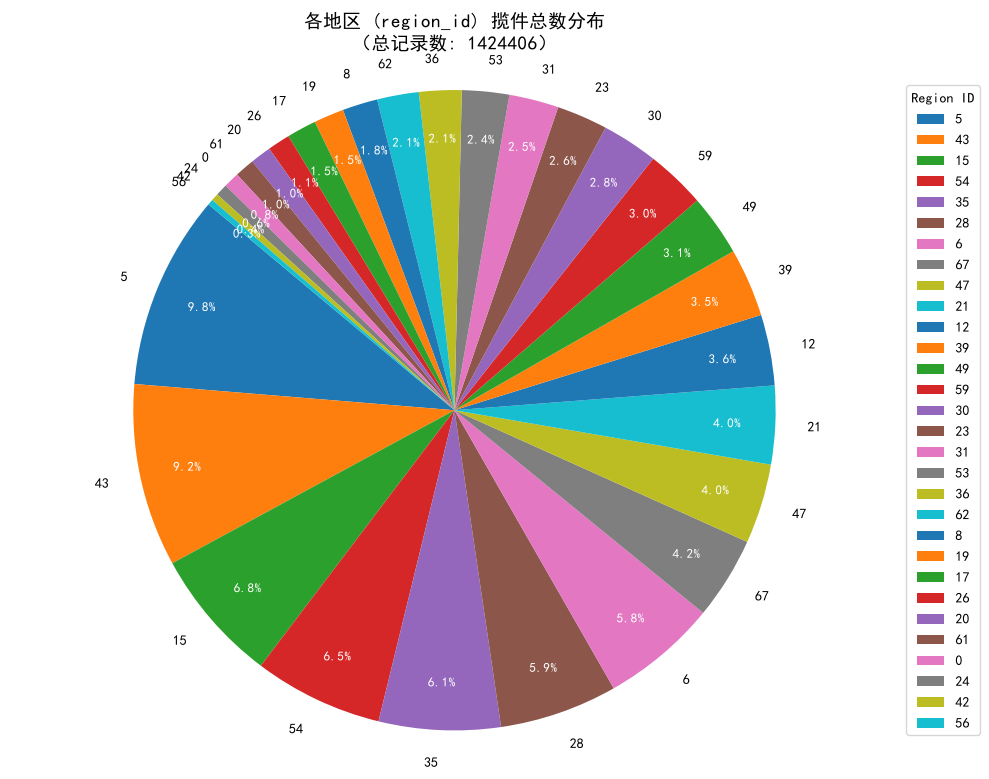

In [4]:
df_pickup = load_pickup()

region_counts = df_pickup['region_id'].value_counts()

# 数量低于阈值的区域归为「其他」
threshold = 10
small = region_counts[region_counts < threshold]
if not small.empty:
    region_counts = region_counts[region_counts >= threshold]
    region_counts['其他'] = small.sum()

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    region_counts,
    labels=region_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
)

# 设置饼图上的百分比文字颜色和字体大小
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(9)

ax.legend(wedges, region_counts.index, title="Region ID", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
ax.set_title(f'各地区 (region_id) 揽件总数分布\n（总记录数: {len(df_pickup)}）', fontsize=14)
ax.axis('equal')
plt.tight_layout()
plt.show()

## 4. Top5 区域月揽件数柱状图

观察各区域在不同月份的揽件量变化。月度数据时间跨度较短，不适合检验月度季节性。

findfont: Failed to find font weight bold, now using 400.


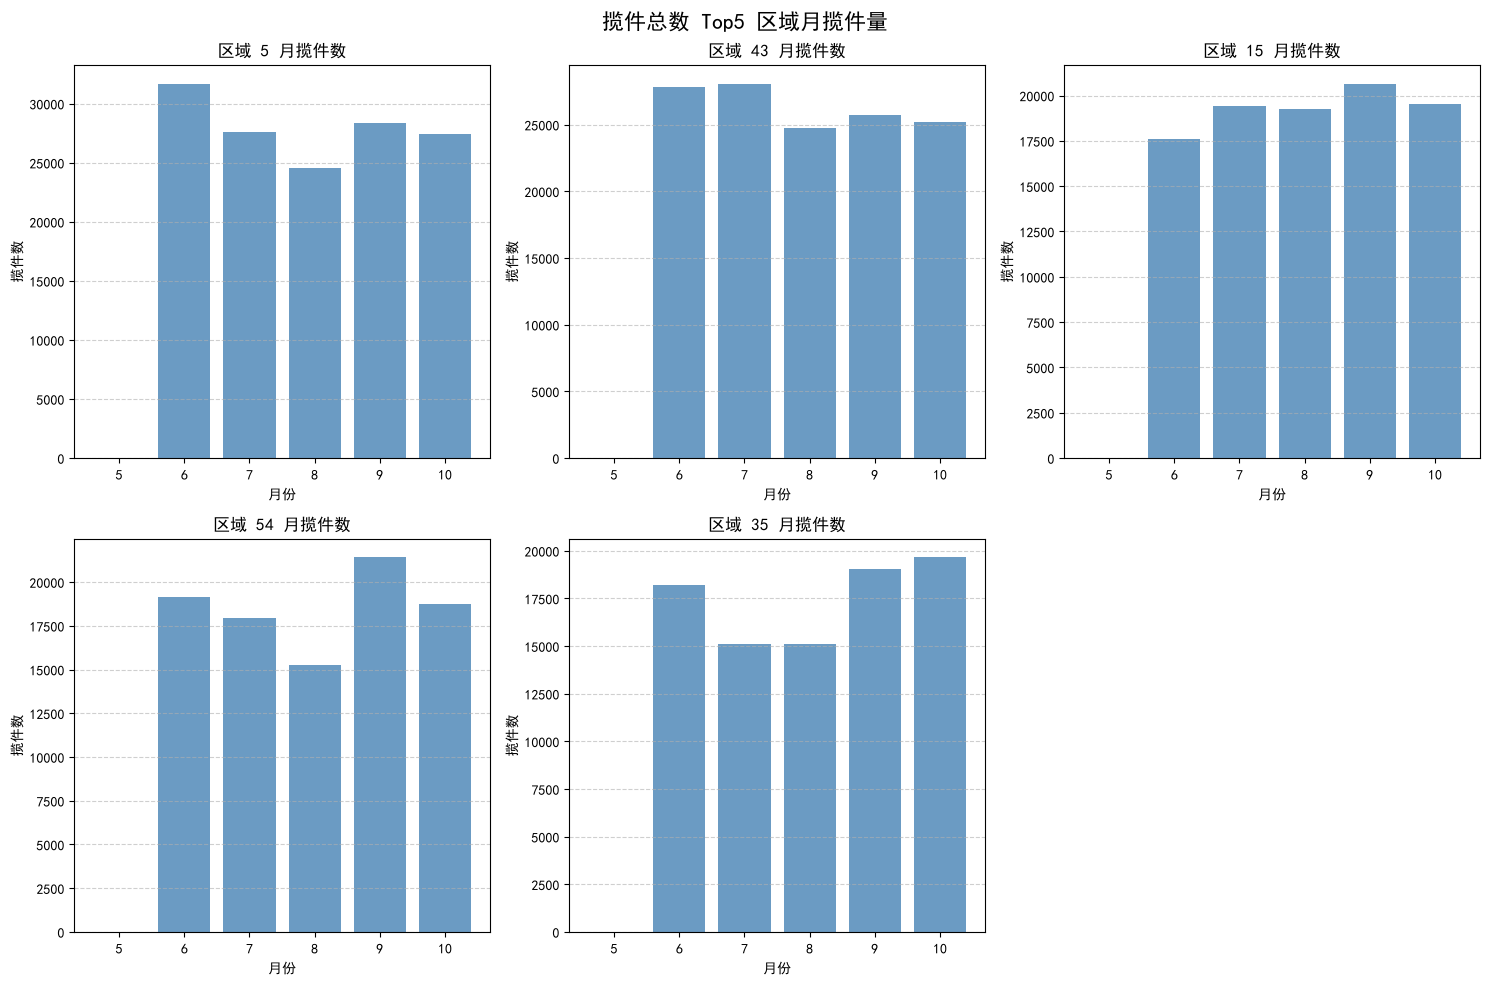

In [5]:
df_pickup = load_pickup()
df_top = df_pickup[df_pickup['region_id'].isin(TOP5)].copy()

# 提取月份并聚合
df_top['month'] = df_top['ds'] // 100
monthly_counts = (
    df_top.groupby(['region_id', 'month'])
          .size()
          .reset_index(name='count')
)
all_months = sorted(monthly_counts['month'].unique())

# 绘图：2行3列，最后一格留空
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=False)
axes = axes.flatten()

for idx, region in enumerate(TOP5):
    ax = axes[idx]
    sub = (
        monthly_counts[monthly_counts['region_id'] == region]
          .set_index('month')
          .reindex(all_months, fill_value=0)
    )
    ax.bar(sub.index.astype(str), sub['count'], color='steelblue', alpha=0.8)
    ax.set_title(f'区域 {region} 月揽件数', fontsize=12)
    ax.set_xlabel('月份')
    ax.set_ylabel('揽件数')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

axes[5].set_visible(False)   # 隐藏第6个多余子图
fig.suptitle('揽件总数 Top5 区域月揽件量', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. 异常时段说明与清洗

观察到各区域在开始2～9天内（5月）出现极低揽件数，疑似数据缺失，按以下规则剔除：

| 区域 | 剔除日期范围 |
|------|-------------|
| 54   | 5/20 ~ 6/1  |
| 43   | 5/25 ~ 6/2  |
| 35   | 5/26 ~ 6/2  |
| 15   | 6/1  ~ 6/2  |
| 5    | 5/29 ~ 6/2  |

> 10月内部分区域仍有几天异常低值，属于未知异常，实际需先确认数据完整性，再与业务方核实根因。

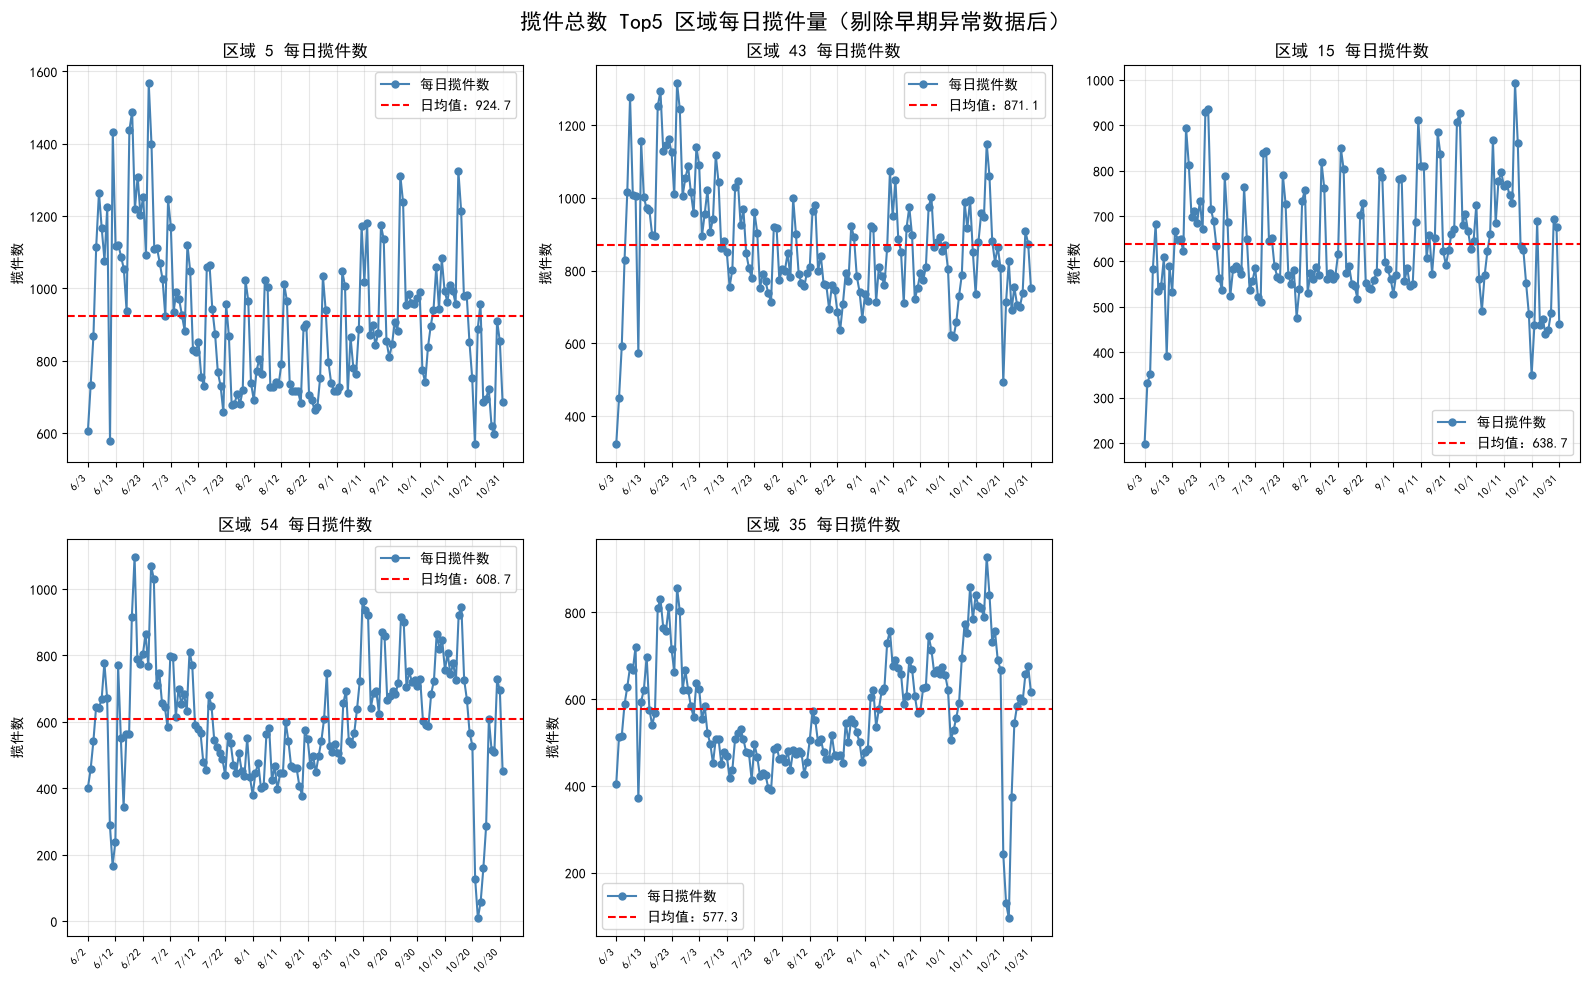

In [6]:
# 加载并清洗数据（REMOVE_RULES 已在 Cell 0 中定义）
df_pickup  = load_pickup()
df_cleaned = filter_top5(df_pickup)
daily      = make_daily(df_cleaned)

# 绘制每日揽件折线图
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, region in enumerate(TOP5):
    ax  = axes[idx]
    sub = daily[daily['region_id'] == region]
    if sub.empty:
        ax.set_visible(False)
        continue

    x      = range(len(sub))
    labels = sub['date_label'].values
    values = sub['count'].values
    avg    = values.mean()

    ax.plot(x, values, marker='o', linestyle='-', color='steelblue',
            markersize=5, linewidth=1.5, label='每日揽件数')
    ax.axhline(y=avg, color='red', linestyle='--', linewidth=1.5, label=f'日均值：{avg:.1f}')

    step = max(1, len(x) // 15)
    ax.set_xticks(list(x)[::step])
    ax.set_xticklabels(labels[::step], rotation=45, ha='right', fontsize=8)
    ax.set_title(f'区域 {region} 每日揽件数', fontsize=12)
    ax.set_ylabel('揽件数')
    ax.legend()
    ax.grid(alpha=0.3)

axes[5].set_visible(False)
fig.suptitle('揽件总数 Top5 区域每日揽件量（剔除早期异常数据后）', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

观察到5个区域的揽件数都受618大促、国庆假期影响，在后续建模中可以添加节日效应。

## 6. Mann-Kendall 趋势检验

对剔除异常后的月度揽件量序列进行 Mann-Kendall 检验，判断各区域是否存在单调性显著上升/下降趋势。

In [7]:
import pymannkendall as mk  # pip install pymannkendall

df_pickup  = load_pickup()
df_cleaned = filter_top5(df_pickup)

# 月度聚合
df_cleaned['month'] = df_cleaned['ds'] // 100
monthly = (
    df_cleaned.groupby(['region_id', 'month'])
              .size()
              .reset_index(name='count')
              .sort_values(['region_id', 'month'])
)

TREND_LABEL = {'increasing': '上升趋势', 'decreasing': '下降趋势', 'no trend': '无显著趋势'}

print("========== Top5 区域月度揽件量 Mann-Kendall 趋势检验 ==========")
for region in TOP5:
    sub = monthly[monthly['region_id'] == region].sort_values('month')
    ts  = sub['count'].values
    if len(ts) < 3:
        print(f"区域 {region}: 数据点不足 ({len(ts)}), 无法检验。")
        continue
    result = mk.original_test(ts)
    print(f"区域 {region:2d}:")
    print(f"    趋势方向: {TREND_LABEL.get(result.trend, result.trend)}")
    print(f"    p 值: {result.p:.4f}")
    print(f"    tau 相关系数: {result.Tau:.4f}")
    print(f"    Sen's 斜率: {result.slope:.2f} 件/月")
    print(f"    参与检验的月份数: {len(sub)}")
    print()

========== Top5 区域月度揽件量 Mann-Kendall 趋势检验 ==========
区域  5:
    趋势方向: 无显著趋势
    p 值: 0.4624
    tau 相关系数: -0.4000
    Sen's 斜率: -965.00 件/月
    参与检验的月份数: 5

区域 43:
    趋势方向: 无显著趋势
    p 值: 0.4624
    tau 相关系数: -0.4000
    Sen's 斜率: -666.96 件/月
    参与检验的月份数: 5

区域 15:
    趋势方向: 无显著趋势
    p 值: 0.2207
    tau 相关系数: 0.6000
    Sen's 斜率: 558.38 件/月
    参与检验的月份数: 5

区域 54:
    趋势方向: 无显著趋势
    p 值: 1.0000
    tau 相关系数: 0.0000
    Sen's 斜率: 87.38 件/月
    参与检验的月份数: 5

区域 35:
    趋势方向: 无显著趋势
    p 值: 0.2207
    tau 相关系数: 0.6000
    Sen's 斜率: 478.38 件/月
    参与检验的月份数: 5



## 7. ADF 单位根检验（日揽件量平稳性）

对各区域每日揽件量进行 ADF 检验；若原始序列非平稳，进一步检验一阶差分序列。

In [8]:
df_pickup  = load_pickup()
df_cleaned = filter_top5(df_pickup)
daily      = make_daily(df_cleaned)

print("========== Top5 区域日揽件量 ADF 单位根检验 ==========\n")

for region in TOP5:
    sub    = daily[daily['region_id'] == region]
    series = sub['count'].values
    print(f"区域 {region} (数据天数: {len(series)})")

    stat, p, is_stationary = adf_test(series)
    print(f"  原始序列:")
    print(f"    ADF 统计量: {stat:.4f}")
    print(f"    p 值: {p:.4f}")
    print(f"    结论: {'平稳（无单位根）' if is_stationary else '非平稳（存在单位根/趋势）'}")

    if not is_stationary:
        diff = pd.Series(series).diff().dropna().values
        if len(diff) > 2:
            stat_d, p_d, stationary_d = adf_test(diff)
            print(f"  一阶差分后:")
            print(f"    ADF 统计量: {stat_d:.4f}")
            print(f"    p 值: {p_d:.4f}")
            print(f"    结论: {'平稳' if stationary_d else '仍非平稳'}")
        else:
            print(f"  差分后数据不足，无法检验")
    print("-" * 50)

========== Top5 区域日揽件量 ADF 单位根检验 ==========

区域 5 (数据天数: 151)
  原始序列:
    ADF 统计量: -1.5984
    p 值: 0.4844
    结论: 非平稳（存在单位根/趋势）
  一阶差分后:
    ADF 统计量: -4.9053
    p 值: 0.0000
    结论: 平稳
--------------------------------------------------
区域 43 (数据天数: 151)
  原始序列:
    ADF 统计量: -1.7946
    p 值: 0.3831
    结论: 非平稳（存在单位根/趋势）
  一阶差分后:
    ADF 统计量: -4.9651
    p 值: 0.0000
    结论: 平稳
--------------------------------------------------
区域 15 (数据天数: 151)
  原始序列:
    ADF 统计量: -3.6076
    p 值: 0.0056
    结论: 平稳（无单位根）
--------------------------------------------------
区域 54 (数据天数: 152)
  原始序列:
    ADF 统计量: -2.7556
    p 值: 0.0649
    结论: 非平稳（存在单位根/趋势）
  一阶差分后:
    ADF 统计量: -5.6667
    p 值: 0.0000
    结论: 平稳
--------------------------------------------------
区域 35 (数据天数: 151)
  原始序列:
    ADF 统计量: -3.8737
    p 值: 0.0022
    结论: 平稳（无单位根）
--------------------------------------------------


## 8. ACF 自相关图

观察各区域日揽件量的自相关结构，识别周期性信号。
非平稳序列自动使用一阶差分后再绘图。

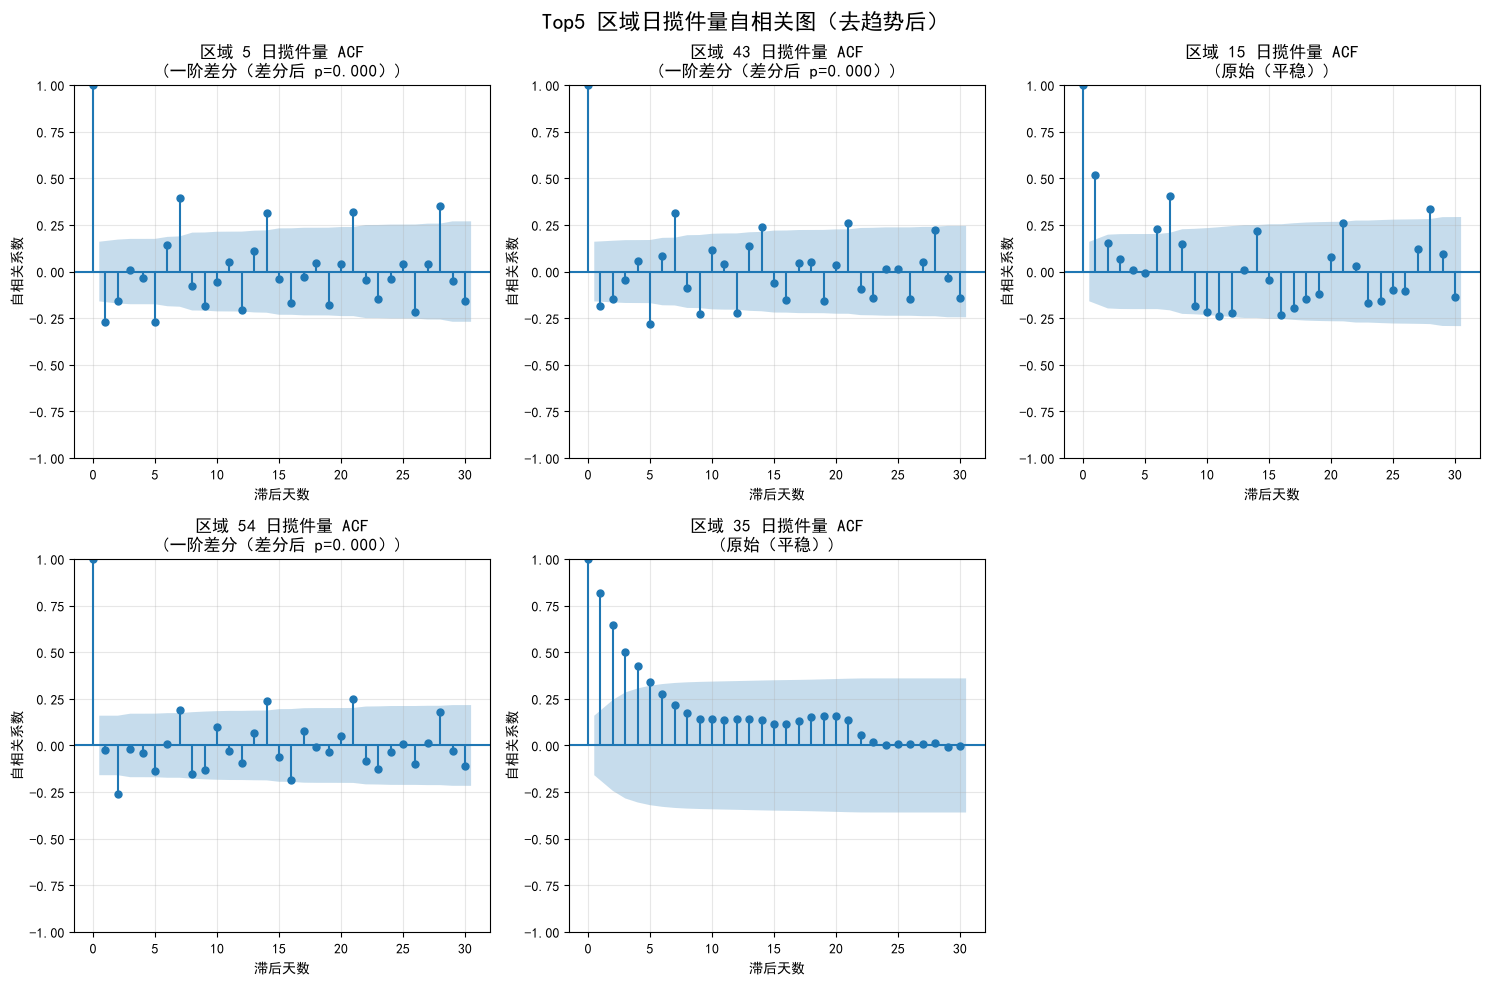

In [9]:
from statsmodels.graphics.tsaplots import plot_acf

df_pickup  = load_pickup()
df_cleaned = filter_top5(df_pickup)
daily      = make_daily(df_cleaned)

LAGS = 30

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, region in enumerate(TOP5):
    ax         = axes[idx]
    sub        = daily[daily['region_id'] == region]
    series_raw = sub['count'].values
    series_used, note = get_stationary_series(series_raw)

    if len(series_used) < 2:
        ax.text(0.5, 0.5, f'区域 {region} 数据不足', ha='center', va='center')
        continue

    plot_acf(
        series_used,
        lags=min(LAGS, len(series_used) - 1),
        ax=ax,
        title=f'区域 {region} 日揽件量 ACF\n({note})'
    )
    ax.set_xlabel('滞后天数')
    ax.set_ylabel('自相关系数')
    ax.grid(alpha=0.3)

axes[5].set_visible(False)
fig.suptitle('Top5 区域日揽件量自相关图（去趋势后）', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

观察到区域5存在显著的周周期性，一周中周日和周一的揽件量最高，周五和周六最少。

## 9. Prophet 时间序列预测（以区域5为例）

区域5存在显著7天周期性，并受618大促等节日影响。
建模策略：
- 关闭内置年/日季节性（数据不足一年）
- 添加周季节性
- 加入618、国庆虚拟变量

以下参数为网格搜索调优后模型参数

Importing plotly failed. Interactive plots will not work.


区域5有效数据范围: 2023-06-03 ~ 2023-10-31, 共 151 天


16:09:35 - cmdstanpy - INFO - Chain [1] start processing
16:09:35 - cmdstanpy - INFO - Chain [1] done processing


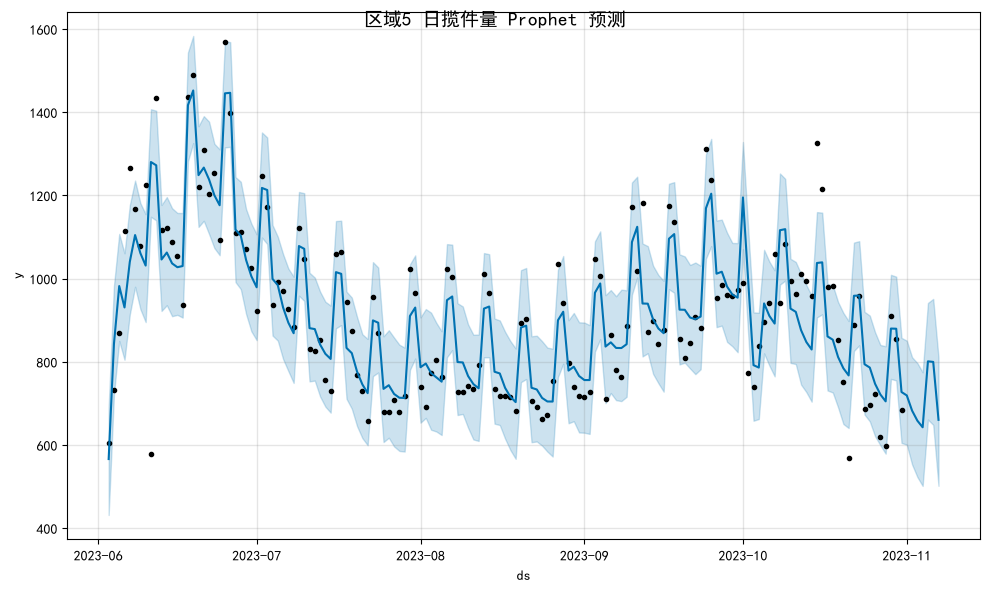

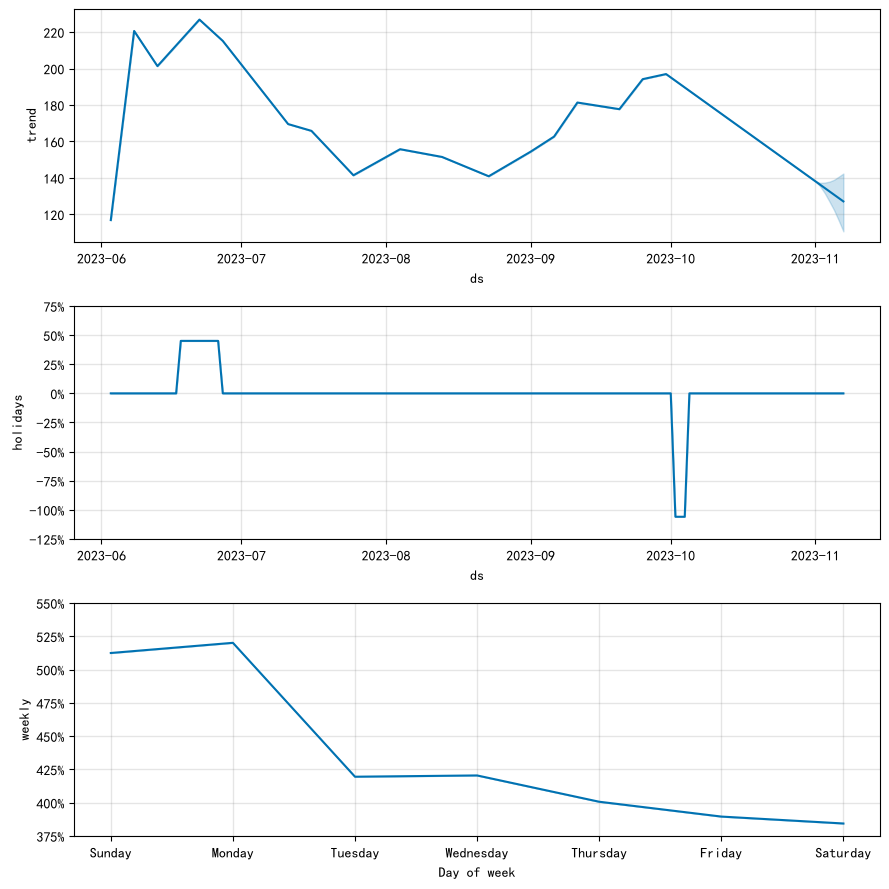

In [10]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

REGION_ID   = 5
YEAR        = 2023
PROMO_START = '2023-06-18'          # 618
PROMO_END   = '2023-06-26'          # 618
NATIONAL_START = '2023-10-02'       # 国庆假期
NATIONAL_END   = '2023-10-04'       # 国庆假期
FORECAST_DAYS = 7

# ─── 1. 数据准备 ───────────────────────────────────────────
def ds_to_date(ds_int, year=YEAR):
    """将 MMDD 整数转换为 Timestamp（默认年份 YEAR）。"""
    return pd.Timestamp(year=year, month=ds_int // 100, day=ds_int % 100)

df_pickup  = load_pickup()
df_r5      = df_pickup[df_pickup['region_id'] == REGION_ID].copy()

# 单独剔除区域5的异常时段
start, end = REMOVE_RULES[REGION_ID]
df_r5 = df_r5[(df_r5['ds'] < start) | (df_r5['ds'] > end)]

df_r5['ds'] = df_r5['ds'].apply(ds_to_date)
daily_r5    = df_r5.groupby('ds').size().reset_index(name='y').sort_values('ds').reset_index(drop=True)

print(f"区域{REGION_ID}有效数据范围: {daily_r5['ds'].min().date()} ~ {daily_r5['ds'].max().date()}, 共 {len(daily_r5)} 天")

# ─── 2. 节假日/大促定义 ────────────────────────────────────
promo_holidays = pd.DataFrame({
    'holiday': 'mid_year_promo',
    'ds': pd.date_range(start=PROMO_START, end=PROMO_END),
    'lower_window': 0,
    'upper_window': 0,
})

# 国庆假期（揽收量降低）
national_holidays = pd.DataFrame({
    'holiday': 'national_day',
    'ds': pd.date_range(start=NATIONAL_START, end=NATIONAL_END),
    'lower_window': 0,
    'upper_window': 0,
})

holidays = pd.concat([promo_holidays, national_holidays], ignore_index=True)

# ─── 3. 模型配置与训练 ─────────────────────────────────────
model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    holidays=holidays,
    changepoint_prior_scale=1,                # 趋势
    seasonality_prior_scale=15,               # 季节
    holidays_prior_scale=0.5,                 # 假期效应
)

# 周季节性
model.add_seasonality(name='weekly', period=7, fourier_order=15)

model.fit(daily_r5)

# ─── 4. 预测与可视化 ──────────────────────────────────────
future   = model.make_future_dataframe(periods=FORECAST_DAYS)
forecast = model.predict(future)

fig1 = model.plot(forecast)
fig1.suptitle(f'区域{REGION_ID} 日揽件量 Prophet 预测', fontsize=14)
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

# 最终预测值 = 趋势项 * (1 + 周效应系数 + 大促效应系数) （乘法模式下）

## 10. Prophet 模型评估

采用 Prophet 滚动时间窗口交叉验证（initial=60 days，period=7 days，horizon=7 days）评估模型稳定性。对模型进行交叉验证，计算验证集上的 MAE、RMSE、MAPE。


开始交叉验证：initial=60 days, period=7 days, horizon=7 days


  0%|          | 0/12 [00:00<?, ?it/s]

16:09:35 - cmdstanpy - INFO - Chain [1] start processing
16:09:36 - cmdstanpy - INFO - Chain [1] done processing
16:09:36 - cmdstanpy - INFO - Chain [1] start processing
16:09:36 - cmdstanpy - INFO - Chain [1] done processing
16:09:36 - cmdstanpy - INFO - Chain [1] start processing
16:09:37 - cmdstanpy - INFO - Chain [1] done processing
16:09:37 - cmdstanpy - INFO - Chain [1] start processing
16:09:37 - cmdstanpy - INFO - Chain [1] done processing
16:09:37 - cmdstanpy - INFO - Chain [1] start processing
16:09:38 - cmdstanpy - INFO - Chain [1] done processing
16:09:38 - cmdstanpy - INFO - Chain [1] start processing
16:09:38 - cmdstanpy - INFO - Chain [1] done processing
16:09:38 - cmdstanpy - INFO - Chain [1] start processing
16:09:38 - cmdstanpy - INFO - Chain [1] done processing
16:09:38 - cmdstanpy - INFO - Chain [1] start processing
16:09:38 - cmdstanpy - INFO - Chain [1] done processing
16:09:38 - cmdstanpy - INFO - Chain [1] start processing
16:09:38 - cmdstanpy - INFO - Chain [1]

交叉验证共生成 84 条记录

交叉验证性能指标（汇总）：
  horizon           mse        rmse         mae      mape     mdape     smape  \
0  1 days   6065.715214   77.882702   56.906388  0.072014  0.048999  0.068222   
1  2 days   4458.265888   66.770247   48.064389  0.056803  0.033549  0.055196   
2  3 days   8244.554802   90.799531   65.918298  0.086142  0.045454  0.080632   
3  4 days  20982.567489  144.853607  102.223537  0.145005  0.090487  0.128739   
4  5 days  30599.131203  174.926074  148.931356  0.144826  0.134053  0.139336   

   coverage  
0  0.833333  
1  0.916667  
2  0.833333  
3  0.750000  
4  0.666667  


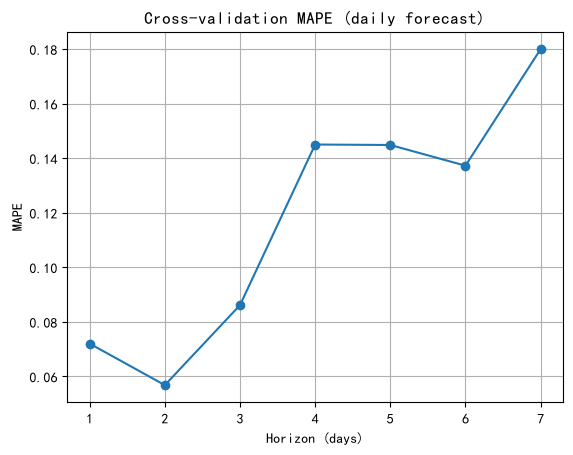

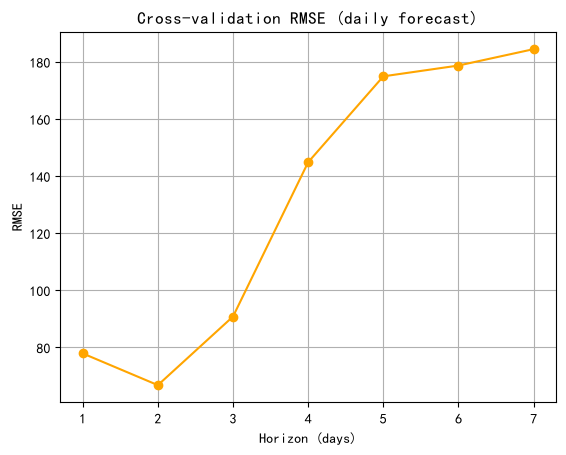

=== 交叉验证整体平均指标 ===
MAPE : 11.74%
RMSE : 139.5456
MAE  : 98.9456


In [11]:
# 模型交叉验证
# 交叉验证参数设置
cv_initial = '60 days'
cv_period  = '7 days'
cv_horizon = '7 days'

print(f"\n开始交叉验证：initial={cv_initial}, period={cv_period}, horizon={cv_horizon}")
df_cv = cross_validation(model, initial=cv_initial, period=cv_period, horizon=cv_horizon)
print(f"交叉验证共生成 {df_cv.shape[0]} 条记录")

# 计算性能指标
df_metrics = performance_metrics(df_cv)
print("\n交叉验证性能指标（汇总）：")
print(df_metrics.head())

#误差可视化
# 1. 计算 horizon（时间差）
df_cv = df_cv.copy()
df_cv['horizon'] = df_cv['ds'] - df_cv['cutoff']

# 2. 计算误差（注意避免除以 0，如果 y 可能为 0 建议过滤或处理）
mask = df_cv['y'] > 0  # 简单过滤 y=0 的样本
df_valid = df_cv[mask].copy()
df_valid['ape'] = np.abs((df_valid['y'] - df_valid['yhat']) / df_valid['y'])
df_valid['se']  = (df_valid['y'] - df_valid['yhat']) ** 2

# 3. 按 horizon 分组计算 MAPE 和 RMSE
horizon_mape = df_valid.groupby('horizon')['ape'].mean().reset_index(name='mape')
horizon_rmse = df_valid.groupby('horizon')['se'].mean().reset_index(name='rmse')
horizon_rmse['rmse'] = np.sqrt(horizon_rmse['rmse'])

# 4. 将 timedelta 转为便于阅读的单位
# ─── 绘制以天为横轴的误差曲线 ─────────────────
# 将 horizon 转为天数（整数）
horizon_mape['horizon_days'] = horizon_mape['horizon'].dt.days
horizon_rmse['horizon_days'] = horizon_rmse['horizon'].dt.days

# 绘图：MAPE
fig3, ax3 = plt.subplots()
ax3.plot(horizon_mape['horizon_days'], horizon_mape['mape'], marker='o')
ax3.set_xlabel('Horizon (days)')
ax3.set_ylabel('MAPE')
ax3.set_title('Cross-validation MAPE (daily forecast)')
ax3.grid(True)
plt.show()

# 绘图：RMSE
fig4, ax4 = plt.subplots()
ax4.plot(horizon_rmse['horizon_days'], horizon_rmse['rmse'], marker='o', color='orange')
ax4.set_xlabel('Horizon (days)')
ax4.set_ylabel('RMSE')
ax4.set_title('Cross-validation RMSE (daily forecast)')
ax4.grid(True)
plt.show()
# ─── 计算交叉验证的整体平均指标─────────────────
# 确保 df_cv 中有 horizon、ape、se 等列；若无则重新计算
if 'horizon' not in df_cv.columns:
    df_cv['horizon'] = df_cv['ds'] - df_cv['cutoff']

if 'ape' not in df_cv.columns:
    mask = df_cv['y'] > 0
    df_cv['ape'] = np.nan
    df_cv.loc[mask, 'ape'] = np.abs((df_cv.loc[mask, 'y'] - df_cv.loc[mask, 'yhat']) / df_cv.loc[mask, 'y'])
    df_cv['ae'] = np.abs(df_cv['y'] - df_cv['yhat'])
    df_cv['se'] = (df_cv['y'] - df_cv['yhat']) ** 2

# 过滤掉 y=0 导致的 inf 值（计算 MAPE 时）
ape_valid = df_cv['ape'].dropna()

mape  = np.mean(ape_valid) * 100          # 百分比形式
rmse  = np.sqrt(np.mean(df_cv['se']))
mae   = np.mean(df_cv['ae'])

print("=== 交叉验证整体平均指标 ===")
print(f"MAPE : {mape:.2f}%")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

结果表明，模型在未来1-3天预测中的 MAPE 控制在约6%~9%，具有较高的预测精度；而预测4天以后误差明显增加，至第7天约为18%。
在实际业务中可采用滚动预测策略：每天利用最新数据重新训练模型，预测未来7天，其中未来1-3天的预测值可辅助运营决策。
若有更多详解数据（促销活动、天气、新增客户、客户流失等），也可结合业务经验修正预测结果。

汇总计算区域5的及时率（pickup_time在time_window_end时间之前为及时）

区域5每日及时率均值: 0.9893 (98.93%)
区域5每日及时率标准差: 0.0058 (0.58%)


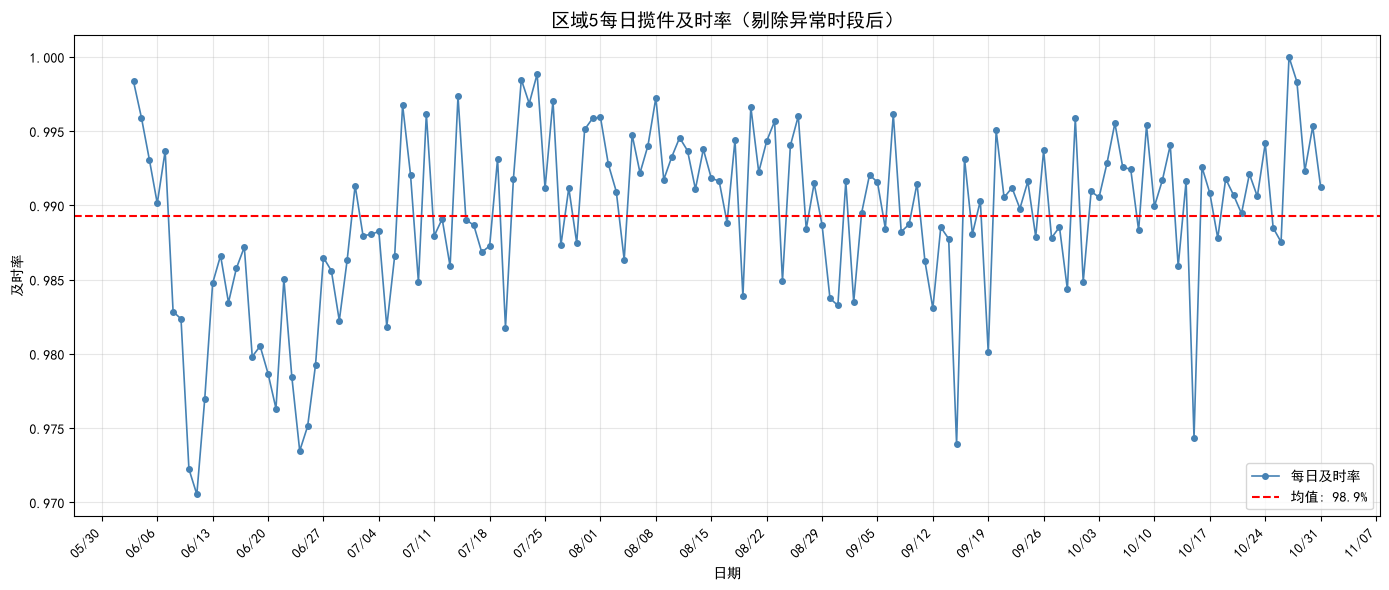

In [12]:
# ==================== 1. 读取数据并筛选区域5 ====================
df = pd.read_csv(r"D:\WORK\作品\transport\pickup_sh.csv", encoding='utf-8')
df_region5 = df[df['region_id'] == 5].copy()
df_region5['ds'] = df_region5['ds'].astype(int)

# 剔除 529~602 异常时段
mask_remove = (df_region5['ds'] >= 529) & (df_region5['ds'] <= 602)
df_clean = df_region5[~mask_remove].copy()

# ==================== 2. 时间解析与及时判定 ====================
df_clean['pickup'] = pd.to_datetime(df_clean['pickup_time'], format='mixed').dt.time
df_clean['win_start'] = pd.to_datetime(df_clean['time_window_start'], format='mixed').dt.time
df_clean['win_end'] = pd.to_datetime(df_clean['time_window_end'], format='mixed').dt.time

# 及时判定：pickup <= win_end 即视为及时
df_clean['on_time'] = df_clean['pickup'] <= df_clean['win_end']

# ==================== 3. 按日统计及时率 ====================
daily_timely = df_clean.groupby('ds').agg(
    total_records=('on_time', 'count'),
    timely_records=('on_time', 'sum')
).reset_index()
daily_timely['timely_rate'] = daily_timely['timely_records'] / daily_timely['total_records']

# 将 ds 整数转换为实际日期（假设年份为 2023）
def ds_to_date(ds_int):
    month = ds_int // 100
    day = ds_int % 100
    return pd.Timestamp(year=2023, month=month, day=day)

daily_timely['date'] = daily_timely['ds'].apply(ds_to_date)
daily_timely = daily_timely.sort_values('date').reset_index(drop=True)

# ==================== 4. 计算均值和标准差 ====================
mean_rate = daily_timely['timely_rate'].mean()
std_rate = daily_timely['timely_rate'].std()
print(f"区域5每日及时率均值: {mean_rate:.4f} ({mean_rate*100:.2f}%)")
print(f"区域5每日及时率标准差: {std_rate:.4f} ({std_rate*100:.2f}%)")

# ==================== 5. 绘制每日及时率折线图====================
fig, ax = plt.subplots(figsize=(14, 6))
dates = daily_timely['date']
ax.plot(dates, daily_timely['timely_rate'], marker='o', linestyle='-', color='steelblue',
        markersize=4, linewidth=1.2, label='每日及时率')
ax.axhline(y=mean_rate, color='red', linestyle='--', linewidth=1.5, label=f'均值: {mean_rate*100:.1f}%')

# 设置日期轴格式
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # 每周一个刻度，可根据需要调整
plt.xticks(rotation=45, ha='right')

ax.set_title('区域5每日揽件及时率（剔除异常时段后）', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('及时率')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

由数据可知区域5揽件业务在时效方面的服务水平高，及时率均值达到98.93%，及时率范围在97%~100%。

## 11. 探索业务量与快递员揽件能力的关系

人均揽件 C 的均值: 18.15


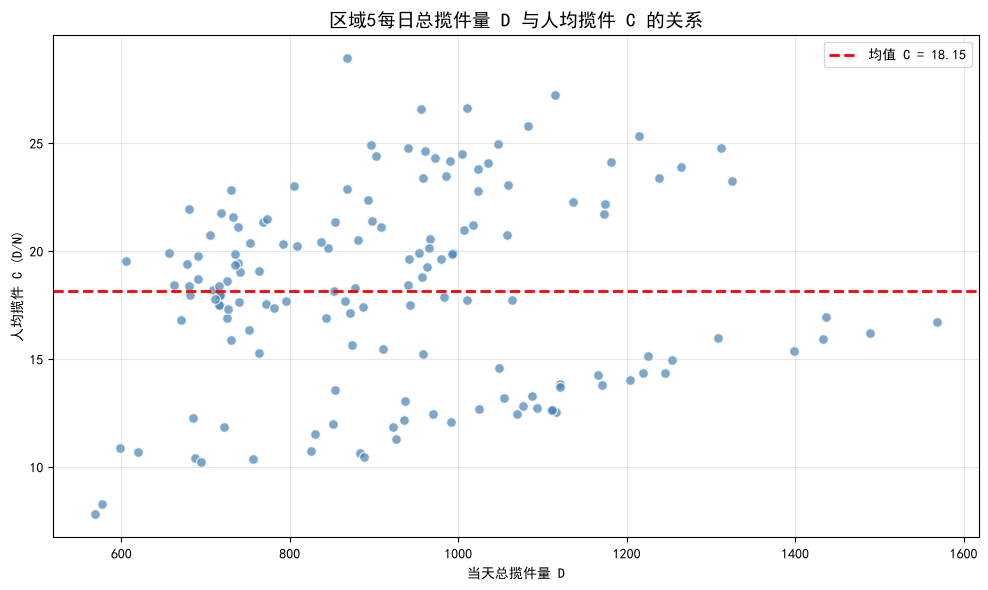

In [13]:
# ====================  按天统计总揽件量 D 和在线人数 N ====================
daily_stats = df_clean.groupby('ds').agg(
    D=('ds', 'count'),                    # 当天揽件总数
    N=('courier_id', 'nunique')           # 当天不同快递员数量
).reset_index()

# 计算人均能力 C
daily_stats['C'] = daily_stats['D'] / daily_stats['N']

# ====================  计算人均揽件的均值 ====================
mean_C = daily_stats['C'].mean()
print(f"人均揽件 C 的均值: {mean_C:.2f}")

# ====================  绘制散点图 ====================
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(daily_stats['D'], daily_stats['C'], alpha=0.7, color='steelblue', edgecolors='white', s=50)
ax.axhline(y=mean_C, color='red', linestyle='--', linewidth=2, label=f'均值 C = {mean_C:.2f}')

ax.set_title('区域5每日总揽件量 D 与人均揽件 C 的关系', fontsize=14)
ax.set_xlabel('当天总揽件量 D')
ax.set_ylabel('人均揽件 C (D/N)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

当日人均揽件数与当日总揽件量没有线性关系，且在同一个业务量下人均揽件数差异非常大，需求量不是影响快递员揽件数的直接因素，快递员当天揽件数受其它因素影响更大。
由于在同一个业务量下人均揽件数差异较大，进一步观察人均揽件数与快递员人数。

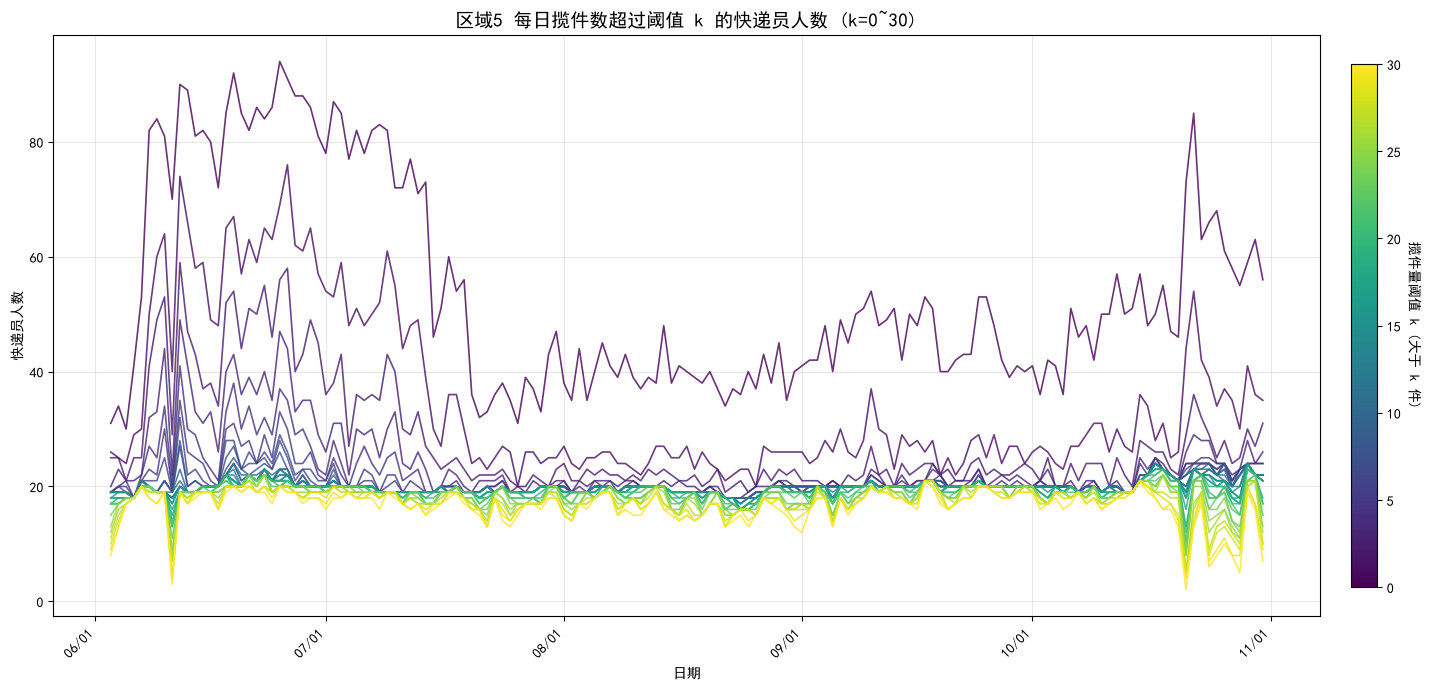

In [14]:
# ====================  计算每位快递员每天的揽件量 ====================
courier_daily = df_clean.groupby(['ds', 'courier_id']).size().reset_index(name='daily_count')

# ====================  对每个阈值 k (0~30)，统计每天快递员人数 ====================
thresholds = list(range(0, 31))  # 0 到 30
daily_counts = {}

for k in thresholds:
    mask = courier_daily['daily_count'] > k
    cnt = courier_daily[mask].groupby('ds').size()
    daily_counts[k] = cnt

# 合并为一个 DataFrame，行为日期（ds），列为阈值 k
date_vs_threshold = pd.DataFrame(daily_counts).fillna(0).astype(int)
date_vs_threshold.sort_index(inplace=True)

# 转换为真实日期
def ds_to_date(ds_int):
    month = ds_int // 100
    day = ds_int % 100
    return pd.Timestamp(year=2026, month=month, day=day)

date_vs_threshold.index = date_vs_threshold.index.map(ds_to_date)

# ====================  绘图 ====================
fig, ax = plt.subplots(figsize=(16, 7))

cmap = plt.get_cmap('viridis')
norm = Normalize(vmin=thresholds[0], vmax=thresholds[-1])

for k in thresholds:
    color = cmap(norm(k))
    ax.plot(date_vs_threshold.index, date_vs_threshold[k], 
            color=color, linewidth=1.2, alpha=0.8)

# 颜色条
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.9, pad=0.02)
cbar.set_label('揽件量阈值 k (大于 k 件)', rotation=270, labelpad=15)

# 格式美化
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('日期')
ax.set_ylabel('快递员人数')
ax.set_title('区域5 每日揽件数超过阈值 k 的快递员人数 (k=0~30)', fontsize=14)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

发现大量快递员的当日揽件数过小（单日1~6件），推测可能由于预约时间窗、路线等因素，存在较多弹性资源处理揽件任务（临时调度的快递员、临时工、机动班）。

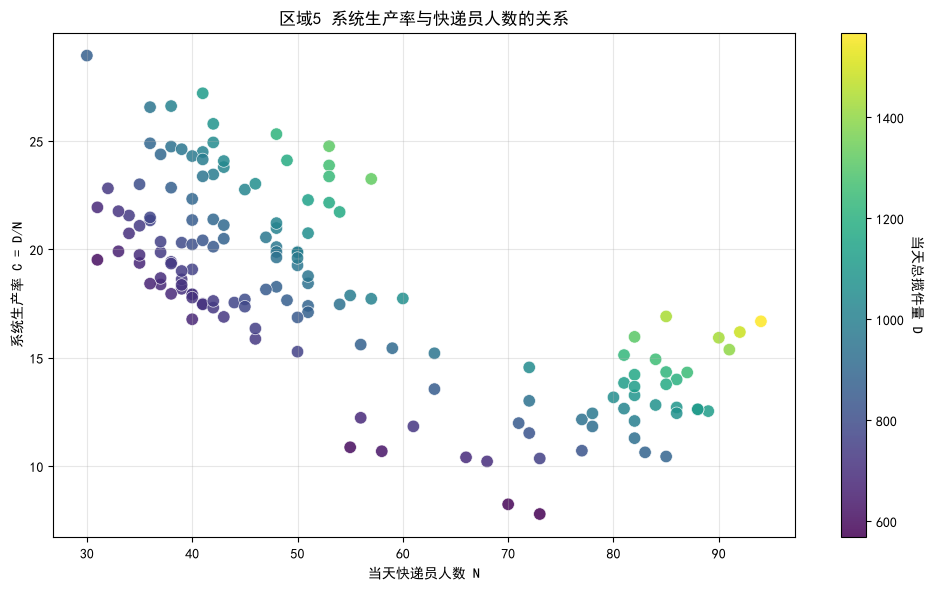

In [15]:
# ==================== 2. 按天计算 N、D、C ====================
daily_stats = df_clean.groupby('ds').agg(
    N=('courier_id', 'nunique'),  # 当天作业总人数（快递员总数）
    D=('ds', 'count')            # 当天总揽件量
).reset_index()

daily_stats['C'] = daily_stats['D'] / daily_stats['N']   # 系统生产率

# ==================== 3. 绘制散点图 ====================
fig, ax = plt.subplots(figsize=(10, 6))

# 以 N 为横轴，C 为纵轴，点的颜色代表 D
sc = ax.scatter(
    daily_stats['N'], daily_stats['C'],
    c=daily_stats['D'],                # 颜色映射 D
    cmap='viridis',                    # 颜色主题
    s=80,                              # 点大小固定，也可改用 size 参数
    edgecolors='white', linewidth=0.5,
    alpha=0.85
)

# 颜色条
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('当天总揽件量 D', rotation=270, labelpad=15)

# 标注
ax.set_xlabel('当天快递员人数 N')
ax.set_ylabel('系统生产率 C = D/N')
ax.set_title('区域5 系统生产率与快递员人数的关系')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

系统生产率（D/N）与人数N存在明显负相关，如果不是由于其它因素存在较多弹性资源处理揽件任务，便意味着目前区域5的人力投入很可能存在"过量投入→人均效率下降"的现象。

每日核心作业人数与核心人均揽件数（前10天）:
      date  total_D  total_N  effective_N  effective_avg
2026-06-03      605       31           19      30.473684
2026-06-04      733       34           19      36.789474
2026-06-05      868       30           18      46.000000
2026-06-06     1115       41           18      59.500000
2026-06-07     1265       53           20      60.150000
2026-06-08     1166       82           39      28.461538
2026-06-09     1077       84           47      21.808511
2026-06-10     1225       81           46      25.326087
2026-06-11      577       70           42      13.071429
2026-06-12     1433       90           51      26.725490

所有日期的核心人均揽件数均值: 36.48


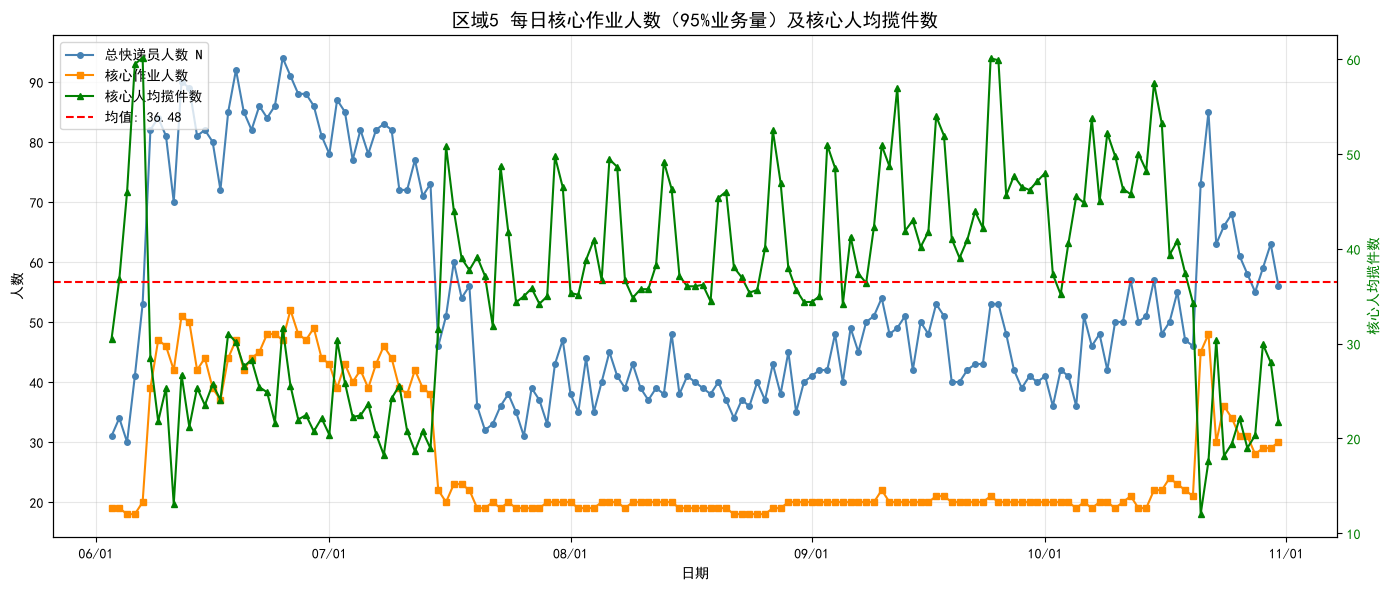

In [16]:
# ====================  每日每位快递员揽件量 ====================
courier_daily = df_clean.groupby(['ds', 'courier_id']).size().reset_index(name='cnt')

# ====================  定义计算核心作业人数和核心人均揽件数的函数 ====================
def calc_effective(df_day, pct=0.95):
    """对某一日的数据，按cnt降序排列，计算达到pct业务量的最少人数"""
    df_sorted = df_day.sort_values('cnt', ascending=False)
    total = df_sorted['cnt'].sum()
    cumsum = df_sorted['cnt'].cumsum()
    # 找到累计占比首次 >= pct 的位置
    idx = (cumsum >= total * pct).idxmax()
    # 有效人数 = 该位置的序号（从1开始）
    effective_n = df_sorted.index.get_loc(idx) + 1
    effective_total = cumsum.loc[idx]
    return effective_n, effective_total

# 按天应用
daily_stats = courier_daily.groupby('ds').apply(
    lambda g: pd.Series({
        'total_D': g['cnt'].sum(),
        'total_N': g['courier_id'].nunique(),
        'effective_N': calc_effective(g)[0],
        'effective_total': calc_effective(g)[1]
    })
).reset_index()

# 计算每日核心人均揽件数
daily_stats['effective_avg'] = daily_stats['effective_total'] / daily_stats['effective_N']

# 将所有日期的核心人均揽件数求均值
mean_effective_avg = daily_stats['effective_avg'].mean()

# 将 ds 转换为真实日期
def ds_to_date(ds_int):
    month = ds_int // 100
    day = ds_int % 100
    return pd.Timestamp(year=2026, month=month, day=day)

daily_stats['date'] = daily_stats['ds'].apply(ds_to_date)
daily_stats = daily_stats.sort_values('date').reset_index(drop=True)

# ====================  输出表格（前10天示例）====================
print("每日核心作业人数与核心人均揽件数（前10天）:")
print(daily_stats[['date', 'total_D', 'total_N', 'effective_N', 'effective_avg']].head(10).to_string(index=False))
print(f"\n所有日期的核心人均揽件数均值: {mean_effective_avg:.2f}")

# ====================  绘制图表（含均值线）====================
fig, ax1 = plt.subplots(figsize=(14, 6))

# 左轴：人数（总人数与有效人数）
ax1.plot(daily_stats['date'], daily_stats['total_N'], 
         color='steelblue', marker='o', markersize=4, linewidth=1.5, label='总快递员人数 N')
ax1.plot(daily_stats['date'], daily_stats['effective_N'], 
         color='darkorange', marker='s', markersize=4, linewidth=1.5, label='核心作业人数')
ax1.set_xlabel('日期')
ax1.set_ylabel('人数', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(alpha=0.3)

# 右轴：有效人均揽件数 + 均值线
ax2 = ax1.twinx()
ax2.plot(daily_stats['date'], daily_stats['effective_avg'], 
         color='green', marker='^', markersize=4, linewidth=1.5, linestyle='-', label='核心人均揽件数')
ax2.axhline(y=mean_effective_avg, color='red', linestyle='--', linewidth=1.5,
            label=f'均值: {mean_effective_avg:.2f}')
ax2.set_ylabel('核心人均揽件数', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
plt.xticks(rotation=45, ha='right')
plt.title('区域5 每日核心作业人数（95%业务量）及核心人均揽件数', fontsize=14)
fig.tight_layout()
plt.show()

观察核心作业人数占比
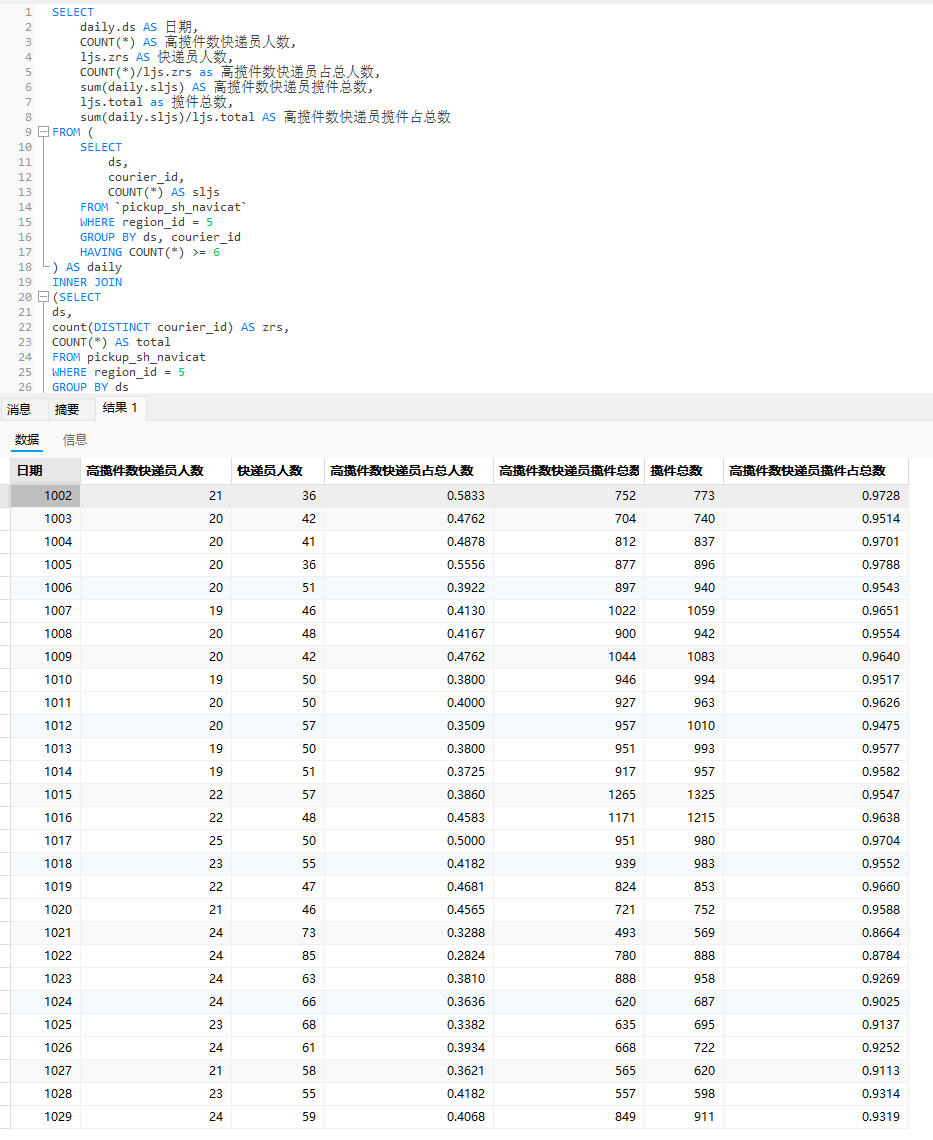

数据说明核心作业人数几乎恒定，在非大促期间，无论业务量600件还是1300件，核心人员始终在21人左右，在618大促期间，核心人员会上升到40~50人，占当日总人数55%左右。
核心人员完成了绝大部分业务，额外增加的人并没有贡献很多业务，大量新增人员不是为了提高生产效率，而是为了覆盖由于订单地理位置、预约时间窗、路线等因素产生的特殊订单。

根据历史数据分析发现，区域5长期存在稳定的核心作业团队（约20人），其承担约85%~97%的揽件任务；其余人员主要承担时间窗冲突、偏远路线及临时支援任务。
Prophet模型能够较准确预测未来业务总量（MAPE≈8%），但由于缺乏订单地理位置、预约时间窗、路线等关键变量，仅凭业务总量无法唯一确定每日所需作业人数，因此模型适用于业务量预测，不适用于生成人员排班计划。生成可解释性强的人员排班计划需要使用地理位置、预约时间窗、路线等变量预测小时颗粒度的各区域业务量，再安排核心运力资源与弹性运力资源。

# 运营建议
基于 Prophet 模型可实现区域揽件需求的短期预测（未来3天滚动预测 MAPE 约为8%），建议将预测结果作为运力规划的前置参考，提前识别业务高峰并预留弹性运力。快递员历史作业分析表明，区域长期存在约21名稳定的核心作业人员，其承担了约85%～97%的揽件任务，运营应优先保障核心运力的稳定配置；其余人员更多承担偏远件、时间窗冲突订单及跨区域支援等弹性任务，建议采用"固定核心运力+弹性人力储备"的配置模式，而非仅依据预测业务量线性增加人员。同时，本项目发现，仅利用每日业务总量无法准确推导所需排班人数，实际排班还受到订单空间分布、预约时间窗及调度策略等因素影响。因此，如果需要提升人力资源利用率和运营效率，建议企业利用订单地理位置、预约时间及路线等数据，构建更细粒度的时空需求预测与运力调度模型。